## EU 아마존 Price 추이

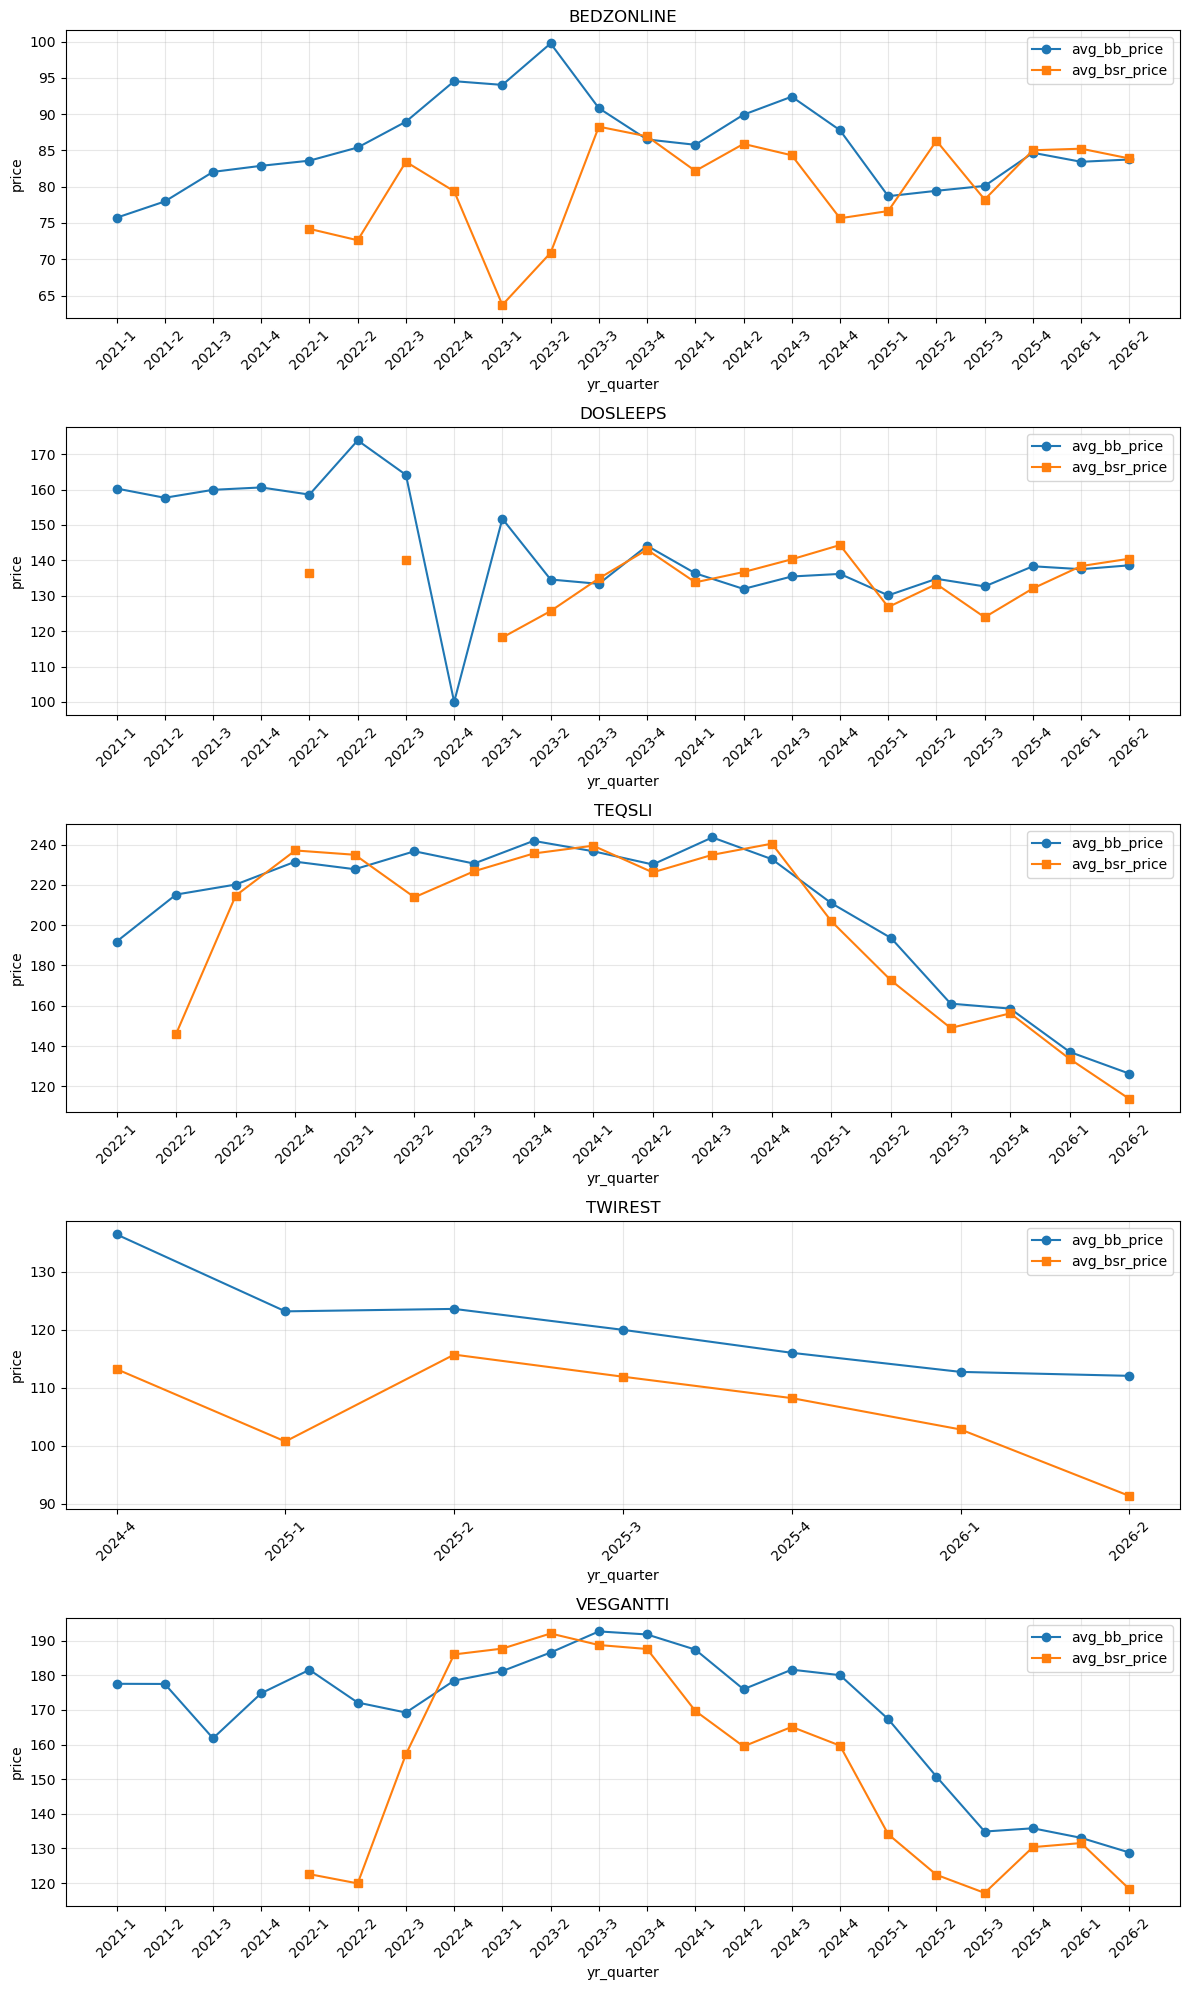

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('uk_amz_comp_price_0415.csv')

# yr_quarter 정렬을 위한 정리 (예: '2021-1' -> 정렬 가능하도록)
df['yr_quarter'] = df['yr_quarter'].astype(str)
df = df.sort_values(['brand', 'yr_quarter'])

# 브랜드 목록
brands = df['brand'].unique()
n = len(brands)

# 서브플롯 생성 (브랜드별 1개씩)
fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n))
if n == 1:
    axes = [axes]

for ax, brand in zip(axes, brands):
    sub = df[df['brand'] == brand]
    ax.plot(sub['yr_quarter'], sub['avg_bb_price'], marker='o', label='avg_bb_price')
    ax.plot(sub['yr_quarter'], sub['avg_bsr_price'], marker='s', label='avg_bsr_price')
    ax.set_title(f'{brand}')
    ax.set_xlabel('yr_quarter')
    ax.set_ylabel('price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('brand_price_trends.png', dpi=120)
plt.show()